<a href="https://colab.research.google.com/github/mukeshrock7897/Artificial-Intelligence-Notes/blob/main/3_TSA(Time_Series_Analysis)_Advanced_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Advanced Level**
1. Machine Learning for Time Series
    * Feature engineering for time series data
    * Regression models for forecasting (e.g., Linear Regression, Decision Trees)
    * Ensemble methods (e.g., Random Forest, Gradient Boosting)

2. Deep Learning for Time Series
    * Recurrent Neural Networks (RNNs)
    * Long Short-Term Memory Networks (LSTMs)
    * Gated Recurrent Units (GRUs)
    * Temporal Convolutional Networks (TCNs)

3. Advanced Topics in Time Series Analysis
    * Multivariate time series analysis
    * State space models and the Kalman filter
    * Anomaly detection in time series
    * Change point detection

4. Time Series in Practice
    * Case studies and applications in finance, healthcare, and other industries
    * Implementing end-to-end time series forecasting projects
    * Using software tools and libraries (e.g., Python, R, TensorFlow, Keras)

5. Advanced Forecasting Techniques
    * Prophet by Facebook
    * Hybrid models (combining statistical and machine learning models)
    * Bayesian methods for time series analysis

6. Big Data Time Series
    * Handling large-scale time series data
    * Time series databases (e.g., InfluxDB, TimescaleDB)
    * Real-time processing and forecasting

# **1. Machine Learning for Time Series**
**Feature Engineering for Time Series Data**
* Feature engineering involves creating new features from the time series data to improve model performance.

**Example:**

In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate date range
date_range = pd.date_range(start='2020-01-01', periods=1000, freq='D')

# Generate synthetic time series data
trend = np.linspace(0, 1, 1000)  # Linear trend
seasonality = np.sin(np.linspace(0, 20 * np.pi, 1000))  # Seasonal component
noise = np.random.normal(scale=0.1, size=1000)  # Random noise

# Combine components to create the time series
values = trend + seasonality + noise

# Create DataFrame
df = pd.DataFrame({'date': date_range, 'value': values})

# Set the date column as the index
df.set_index('date', inplace=True)

# Display the first few rows of the DataFrame
print(df.head())

# Create lag features
df['lag_1'] = df['value'].shift(1)
df['lag_2'] = df['value'].shift(2)

# Create rolling mean features
df['rolling_mean_3'] = df['value'].rolling(window=3).mean()

# Drop missing values generated by shifting
df.dropna(inplace=True)

# Display the first few rows of the DataFrame after creating features
print(df.head())

               value
date                
2020-01-01  0.049671
2020-01-02  0.050028
2020-01-03  0.192229
2020-01-04  0.342873
2020-01-05  0.229522
               value     lag_1     lag_2  rolling_mean_3
date                                                    
2020-01-03  0.192229  0.050028  0.049671        0.097309
2020-01-04  0.342873  0.192229  0.050028        0.195043
2020-01-05  0.229522  0.342873  0.192229        0.254875
2020-01-06  0.290907  0.229522  0.342873        0.287767
2020-01-07  0.532403  0.290907  0.229522        0.350944


**Regression Models for Forecasting**

* **Linear Regression:**

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split # Import train_test_split

# Prepare features and target variable
X = df[['lag_1', 'lag_2', 'rolling_mean_3']]
y = df['value']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Fit model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predict
predictions_lr = model_lr.predict(X_test)

* **Decision Trees:**

In [5]:
from sklearn.tree import DecisionTreeRegressor

# Fit model
model_dt = DecisionTreeRegressor()
model_dt.fit(X_train, y_train)

# Predict
predictions_dt = model_dt.predict(X_test)


**Ensemble Methods**
* **Random Forest:**

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Fit model
model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X_train, y_train)

# Predict
predictions_rf = model_rf.predict(X_test)


* **Gradient Boosting:**

In [7]:
from sklearn.ensemble import GradientBoostingRegressor

# Fit model
model_gb = GradientBoostingRegressor(n_estimators=100)
model_gb.fit(X_train, y_train)

# Predict
predictions_gb = model_gb.predict(X_test)


# **2. Deep Learning for Time Series**
* **Recurrent Neural Networks (RNNs)**

**Example:**

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Prepare data (reshaping for RNN input)
X_train_rnn = np.expand_dims(X_train, axis=2)
X_test_rnn = np.expand_dims(X_test, axis=2)

# Build model
model_rnn = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dense(1)
])

# Compile and fit model
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train_rnn, y_train, epochs=10, batch_size=32)

# Predict
predictions_rnn = model_rnn.predict(X_test_rnn)


Epoch 1/10
25/25 [==============================] - 2s 4ms/step - loss: 0.2640
Epoch 2/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0185
Epoch 3/10
25/25 [==============================] - 0s 4ms/step - loss: 0.0125
Epoch 4/10
25/25 [==============================] - 0s 5ms/step - loss: 0.0113
Epoch 5/10
25/25 [==============================] - 0s 4ms/step - loss: 0.0103
Epoch 6/10
25/25 [==============================] - 0s 4ms/step - loss: 0.0096
Epoch 7/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0095
Epoch 8/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0088
Epoch 9/10
25/25 [==============================] - 0s 4ms/step - loss: 0.0083
Epoch 10/10
7/7 [==============================] - 0s 3ms/step


* **Long Short-Term Memory Networks (LSTMs)**

**Example:**

In [9]:
from tensorflow.keras.layers import LSTM

# Build model
model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dense(1)
])

# Compile and fit model
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_rnn, y_train, epochs=10, batch_size=32)

# Predict
predictions_lstm = model_lstm.predict(X_test_rnn)


Epoch 1/10
25/25 [==============================] - 1s 3ms/step - loss: 0.6093
Epoch 2/10
25/25 [==============================] - 0s 3ms/step - loss: 0.3926
Epoch 3/10
25/25 [==============================] - 0s 3ms/step - loss: 0.1724
Epoch 4/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0311
Epoch 5/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0182
Epoch 6/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0158
Epoch 7/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0153
Epoch 8/10
25/25 [==============================] - 0s 4ms/step - loss: 0.0151
Epoch 9/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0150
Epoch 10/10
7/7 [==============================] - 0s 2ms/step


* **Gated Recurrent Units (GRUs)**

**Example:**

In [10]:
from tensorflow.keras.layers import GRU

# Build model
model_gru = Sequential([
    GRU(50, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dense(1)
])

# Compile and fit model
model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train_rnn, y_train, epochs=10, batch_size=32)

# Predict
predictions_gru = model_gru.predict(X_test_rnn)


Epoch 1/10
25/25 [==============================] - 1s 3ms/step - loss: 0.4543
Epoch 2/10
25/25 [==============================] - 0s 3ms/step - loss: 0.1155
Epoch 3/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0230
Epoch 4/10
25/25 [==============================] - 0s 4ms/step - loss: 0.0164
Epoch 5/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0149
Epoch 6/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0141
Epoch 7/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0135
Epoch 8/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0132
Epoch 9/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0129
Epoch 10/10
7/7 [==============================] - 0s 2ms/step


* **Temporal Convolutional Networks (TCNs)**

**Example:**

In [11]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Build model
model_tcn = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile and fit model
model_tcn.compile(optimizer='adam', loss='mse')
model_tcn.fit(X_train_rnn, y_train, epochs=10, batch_size=32)

# Predict
predictions_tcn = model_tcn.predict(X_test_rnn)


Epoch 1/10
25/25 [==============================] - 1s 2ms/step - loss: 0.5541
Epoch 2/10
25/25 [==============================] - 0s 2ms/step - loss: 0.1038
Epoch 3/10
25/25 [==============================] - 0s 2ms/step - loss: 0.0237
Epoch 4/10
25/25 [==============================] - 0s 2ms/step - loss: 0.0199
Epoch 5/10
25/25 [==============================] - 0s 2ms/step - loss: 0.0185
Epoch 6/10
25/25 [==============================] - 0s 2ms/step - loss: 0.0181
Epoch 7/10
25/25 [==============================] - 0s 2ms/step - loss: 0.0177
Epoch 8/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0176
Epoch 9/10
25/25 [==============================] - 0s 3ms/step - loss: 0.0169
Epoch 10/10
7/7 [==============================] - 0s 3ms/step


# **3. Advanced Topics in Time Series Analysis**

**Multivariate Time Series Analysis**
* Multivariate time series involve multiple variables that change over time.

**Example:**

In [14]:
# Example dataset with multiple time series
# Check the available columns in your DataFrame
print(df.columns)

# Replace 'other_variable' with an existing column name
df_multivariate = df[['value', 'lag_1']]  # Example: Using 'lag_1' column

# Implementing ARIMA model for multivariate data
from statsmodels.tsa.vector_ar.var_model import VAR

# Fit model
model_var = VAR(df_multivariate)
model_var_fit = model_var.fit()

# Forecast
# Use model_var.endog to access the historical data
forecast_var = model_var_fit.forecast(model_var.endog, steps=10)
print(forecast_var)

Index(['value', 'lag_1', 'lag_2', 'rolling_mean_3'], dtype='object')
[[0.98759012 1.05725828]
 [1.0079946  0.98759012]
 [0.99573075 1.0079946 ]
 [0.99537386 0.99573075]
 [0.99073521 0.99537386]
 [0.98769365 0.99073521]
 [0.9841138  0.98769365]
 [0.9807708  0.9841138 ]
 [0.97738277 0.9807708 ]
 [0.97405173 0.97738277]]


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


**State Space Models and the Kalman Filter**
* State space models are used for analyzing time series data with hidden states.

**Example:**


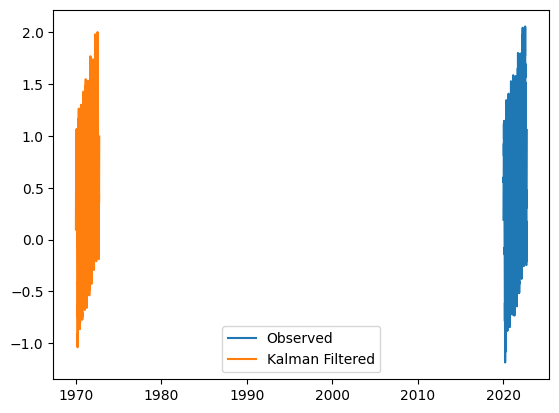

In [17]:
# !pip install pykalman

from pykalman import KalmanFilter
import matplotlib.pyplot as plt

# Implementing Kalman Filter
kf = KalmanFilter(initial_state_mean=0, n_dim_obs=1)

# Fit model
state_means, _ = kf.filter(df['value'])

# Plot results
plt.plot(df['value'], label='Observed')
plt.plot(state_means, label='Kalman Filtered')
plt.legend()
plt.show()

**Anomaly Detection in Time Series**
* Detecting anomalies in time series data using statistical methods or machine learning models.

**Example:**



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-2.0.1-py3-none-any.whl size=193267 sha256=f0ea71a7f360f6026737eb9cc56baa7e340469ea036da007d635a7c127f47de4
  Stored in directory: /root/.cache/pip/wheels/94/75/88/b853cf33b0053b0a001dca55b74d515048b7656e736364eb57
Successfully built pyod


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


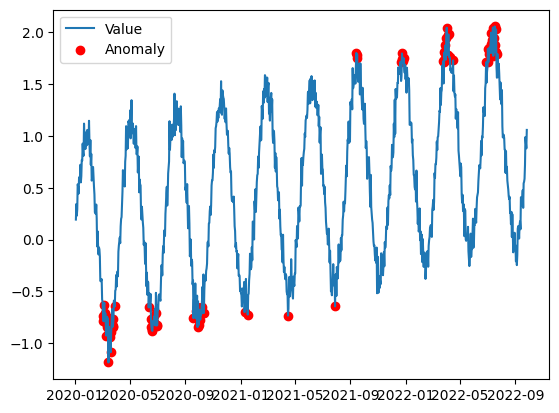

In [19]:
!pip install pyod
from pyod.models.iforest import IForest

# Implementing Isolation Forest for anomaly detection
model_iforest = IForest()
model_iforest.fit(df[['value']])

# Predict anomalies
df['anomaly'] = model_iforest.predict(df[['value']])

# Plot results
plt.plot(df['value'], label='Value')
plt.scatter(df[df['anomaly'] == 1].index, df[df['anomaly'] == 1]['value'], color='red', label='Anomaly')
plt.legend()
plt.show()


**Change Point Detection**
* Identifying points where the statistical properties of a time series change.

**Example:**



In [21]:
!pip install ruptures
import ruptures as rpt

# Implementing change point detection
algo = rpt.Pelt(model="rbf").fit(df['value'].values)
result = algo.predict(pen=10)

# Plot results
rpt.display(df['value'].values, result)
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.0 MB/s eta 0:00:00


# **4. Time Series in Practice**

**Case Studies and Applications**
* **Finance:** Predicting stock prices, risk management.
* **Healthcare:** Monitoring patient vital signs, predicting disease outbreaks.
* **Retail:** Demand forecasting, inventory management.

**Implementing End-to-End Time Series Forecasting Projects**
* Define the problem and gather data.
* Preprocess the data (cleaning, handling missing values, feature engineering).
* Choose and implement a model.
* Train and validate the model.
* Make predictions and evaluate results.
* Deploy the model in production.
* Using Software Tools and Libraries
* Python: pandas, statsmodels, scikit-learn, TensorFlow, Keras
* R: forecast, tseries, zoo
* TensorFlow: For deep learning models
* Keras: For building and training neural networks


# **5. Advanced Forecasting Techniques**
**Prophet by Facebook**

**Example:**

In [24]:
!pip install fbprophet
from fbprophet import Prophet

# Prepare data
df_prophet = df.reset_index().rename(columns={'index': 'ds', 'value': 'y'})

# Fit model
model_prophet = Prophet()
model_prophet.fit(df_prophet)

# Forecast
future = model_prophet.make_future_dataframe(periods=10)
forecast_prophet = model_prophet.predict(future)

# Plot forecast
model_prophet.plot(forecast_prophet)
plt.show()


**Hybrid Models**
* Combining statistical and machine learning models for improved performance.

**Example:**



In [26]:
# Combining ARIMA and Random Forest
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA # Import ARIMA class

# Fit ARIMA model
model_arima = ARIMA(df['value'], order=(5,1,0))
model_arima_fit = model_arima.fit()
residuals = model_arima_fit.resid

# Fit Random Forest model on residuals
model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X_train, residuals.iloc[:-len(X_test)])

# Predict with ARIMA and adjust with Random Forest
predictions_arima = model_arima_fit.forecast(steps=len(X_test))
predictions_rf = model_rf.predict(X_test)
final_predictions = predictions_arima + predictions_rf

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


**Bayesian Methods for Time Series Analysis**
* Using Bayesian inference for time series modeling.

**Example:**



In [2]:
!pip install pymc3
import pymc3 as pm

# Define Bayesian model
with pm.Model() as model_bayesian:
    # Priors for unknown model parameters
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=1)

    # Likelihood (observed data)
    y_obs = pm.Normal('y_obs', mu=alpha + beta * df['lag_1'], sigma=sigma, observed=df['value'])

    # Inference
    trace = pm.sample(1000, return_inferencedata=False)

# Summarize results
pm.summary(trace)


# **6. Big Data Time Series**
**Handling Large-Scale Time Series Data**
* Techniques and tools for managing large volumes of time series data.

**Example:**

In [4]:
import dask.dataframe as dd

# Load large dataset with Dask
df_large = dd.read_csv('large_timeseries.csv')


**Time Series Databases**
* Specialized databases for storing and querying time series data.

**Example with InfluxDB:**



In [8]:
from influxdb import InfluxDBClient

# Connect to InfluxDB
client = InfluxDBClient(host='localhost', port=8086)
client.switch_database('timeseries_db')

# Query data
result = client.query('SELECT * FROM cpu_usage')
points = list(result.get_points())
print(points)


import pandas as pd

# Convert points to DataFrame
df = pd.DataFrame(points)
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

# Display DataFrame
print(df.head())

# Plotting the time series data
import matplotlib.pyplot as plt

df['value'].plot()
plt.title('CPU Usage Over Time')
plt.xlabel('Time')
plt.ylabel('CPU Usage')
plt.show()


**Real-Time Processing and Forecasting**
* Processing and forecasting time series data in real time using tools like Apache Kafka and Spark.

**Example with Apache Kafka and Spark:**

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark session
spark = SparkSession.builder.appName('RealTimeForecast').getOrCreate()

# Read streaming data from Kafka
df_kafka = spark.readStream \
    .format('kafka') \
    .option('kafka.bootstrap.servers', 'localhost:9092') \
    .option('subscribe', 'timeseries_topic') \
    .load()

# Preprocess and forecast (example with moving average)
df_processed = df_kafka.withColumn('value', col('value').cast('double')) \
    .groupBy('timestamp') \
    .agg({'value': 'mean'}) \
    .withColumnRenamed('avg(value)', 'moving_avg')

# Output the forecast to console
query = df_processed.writeStream \
    .outputMode('complete') \
    .format('console') \
    .start()

query.awaitTermination()
